# Drive Me Crazy — 2. Traditional traffic-flow prediction

Before any deep model, three classic forecasters set the bar. The task is PDFormer's: from the last
`T_in` steps of every sensor, predict the next `T_out` steps (12 → 12 five-minute steps on PeMS, i.e. one
hour in / one hour out; 6 → 1 half-hours on NYCTaxi). Windows are split chronologically 60 / 20 / 20 %
(70 / 10 / 20 % for NYCTaxi), and all metrics are computed on the untouched last part.

| model | idea | what it can and cannot do |
|---|---|---|
| **Persistence** | the next hour looks like the last observed value | free, surprisingly hard to beat at 5 minutes, hopeless at 60 |
| **Historical Average** | mean flow for this time-of-day × weekday over the training weeks | captures the daily rhythm, blind to what is happening right now |
| **Ridge regression** | one linear model shared by all sensors: last hour of the sensor + its usual profile for each target slot + weekday, one output per horizon | mixes "now" and "usual" — a linear residual-over-seasonal model; still one sensor at a time (no graph) |

Metrics: MAE, RMSE and MAPE on the original scale, per horizon and averaged over horizons, ignoring
ground-truth gaps (flow = 0) and, for NYCTaxi, cells with fewer than 10 trips — the paper's protocol.

In [ ]:
import os, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

DATA, RESULTS = Path("data"), Path("results")
RESULTS.mkdir(exist_ok=True)

# Per-dataset facts (paper: PDFormer, Jiang et al., AAAI 2023, Table 1) and the forecasting setup PDFormer uses.
# min_true: readings below it are treated as missing when scoring (0 = sensor gap; NYC cells with < 10 trips).
DATASETS = {
    "PEMS04":  dict(step_min=5,  start="2018-01-01", channels=["flow"],              min_true=1,  T_in=12, T_out=12, split=(0.6, 0.2, 0.2)),
    "PEMS08":  dict(step_min=5,  start="2016-07-01", channels=["flow"],              min_true=1,  T_in=12, T_out=12, split=(0.6, 0.2, 0.2)),
    "PEMS07":  dict(step_min=5,  start="2017-05-01", channels=["flow"],              min_true=1,  T_in=12, T_out=12, split=(0.6, 0.2, 0.2)),
    "NYCTaxi": dict(step_min=30, start="2014-01-01", channels=["inflow", "outflow"], min_true=10, T_in=6,  T_out=1,  split=(0.7, 0.1, 0.2)),
}
# DMC_DATASETS="PEMS08" restricts a run (used by the Docker smoke test); default = all four.
SELECTED = [d for d in os.environ.get("DMC_DATASETS", ",".join(DATASETS)).split(",") if d]


def grid_adjacency(rows, cols):
    """8-neighbour adjacency of a rows x cols grid; cell index = row * cols + col."""
    r, c = np.divmod(np.arange(rows * cols), cols)
    adj = (np.abs(r[:, None] - r[None]) <= 1) & (np.abs(c[:, None] - c[None]) <= 1)
    np.fill_diagonal(adj, False)
    return adj.astype(np.float32)


def load_dataset(name):
    """X (T, N, C) float32 targets, adj (N, N) binary symmetric, times DatetimeIndex of length T."""
    cfg = DATASETS[name]
    if name.startswith("PEMS"):
        X = np.load(DATA / f"{name}.npz")["data"][..., :1].astype(np.float32)  # channel 0 = traffic flow
        adj = np.load(DATA / f"adj_{name}.npy").astype(np.float32)
    else:
        df = pd.read_csv(DATA / "NYCTaxi" / "NYCTaxi.grid")
        rows, cols, T = df.row_id.max() + 1, df.column_id.max() + 1, df.time.nunique()
        assert df.dyna_id.is_monotonic_increasing  # cell-major file: every timestep of cell 0, then cell 1, ...
        X = df[cfg["channels"]].to_numpy(np.float32).reshape(rows * cols, T, len(cfg["channels"])).transpose(1, 0, 2)
        adj = grid_adjacency(rows, cols)
    times = pd.date_range(cfg["start"], periods=len(X), freq=f"{cfg['step_min']}min")
    return np.ascontiguousarray(X), adj, times


def time_features(times, step_min):
    """Time-of-day slot index and day-of-week for every timestep."""
    tod = ((times.hour * 60 + times.minute) // step_min).to_numpy()
    return tod, times.dayofweek.to_numpy()


def windows(X, T_in, T_out):
    """Zero-copy sliding windows of length T_in + T_out: (n, T_in + T_out, N, C) view. Index it to copy a batch."""
    return np.moveaxis(sliding_window_view(X, T_in + T_out, axis=0), -1, 1)


def split_indices(n_windows, split):
    """Chronological train / val / test window indices."""
    a, b = int(n_windows * split[0]), int(n_windows * (split[0] + split[1]))
    return np.arange(a), np.arange(a, b), np.arange(b, n_windows)


def masked_metrics(pred, true, min_true):
    """MAE / RMSE / MAPE over entries whose ground truth is >= min_true."""
    m = true >= min_true
    err = (pred - true)[m]
    return dict(MAE=np.abs(err).mean(), RMSE=np.sqrt((err ** 2).mean()), MAPE=100 * (np.abs(err) / true[m]).mean())


def metrics_by_horizon(pred, true, min_true):
    """pred / true (n, T_out, N, C) -> one row per horizon plus an 'avg' row (mean of the per-horizon metrics)."""
    rows = [dict(horizon=str(h + 1), **masked_metrics(pred[:, h], true[:, h], min_true)) for h in range(pred.shape[1])]
    df = pd.DataFrame(rows)
    avg = df.drop(columns="horizon").mean().to_dict()
    return pd.concat([df, pd.DataFrame([dict(horizon="avg", **avg)])], ignore_index=True)


def sample_nodes(adj, X):
    """Three nodes to plot: the best-connected sensor, the busiest, and the quietest (non-dead)."""
    mean_flow = X[..., 0].mean(0)
    alive = np.where(mean_flow > np.percentile(mean_flow, 5))[0]
    return sorted({int(adj.sum(0).argmax()), int(mean_flow.argmax()), int(alive[mean_flow[alive].argmin()])})


def sample_frame(times, test_idx, T_in, T_out, nodes, true, preds, n_days, step_min, model_names):
    """Long table (time, node, actual, <model>_h1, <model>_hLast) over the first n_days of the test period."""
    steps = n_days * 24 * 60 // step_min
    rows = []
    for k in range(min(steps, len(test_idx))):
        w = test_idx[k]
        t1, tL = times[w + T_in], times[w + T_in + T_out - 1]
        for n in nodes:
            rec = dict(time_h1=t1, time_hL=tL, node=n, actual_h1=true[k, 0, n, 0], actual_hL=true[k, -1, n, 0])
            for name, p in zip(model_names, preds):
                rec[f"{name}_h1"], rec[f"{name}_hL"] = p[k, 0, n, 0], p[k, -1, n, 0]
            rows.append(rec)
    return pd.DataFrame(rows)

In [ ]:
from sklearn.linear_model import Ridge

def persistence(x, T_out):
    return np.repeat(x[:, -1:], T_out, axis=1)


def historical_average(X, tod, dow, train_steps, spd):
    # Mean per (weekday, time-of-day slot, node, channel) over the training period; zeros are gaps, so exclude them.
    table = np.zeros((7, spd) + X.shape[1:], np.float64)
    count = np.zeros((7, spd) + X.shape[1:], np.float64)
    valid = X[:train_steps] > 0
    np.add.at(table, (dow[:train_steps], tod[:train_steps]), np.where(valid, X[:train_steps], 0))
    np.add.at(count, (dow[:train_steps], tod[:train_steps]), valid)
    return (table / np.maximum(count, 1)).astype(np.float32)


def ridge_features(x, profile, dow_last):
    # One row per (window, node): the node's standardised history (n, T_in, N, C), the standardised
    # historical-average profile of its T_out target slots (n, T_out, N, C), and the weekday (6 dummies).
    n, T_in, N, C = x.shape
    hist = x.transpose(0, 2, 1, 3).reshape(n * N, T_in * C)
    usual = profile.transpose(0, 2, 1, 3).reshape(n * N, -1)
    week = np.repeat(np.eye(7, dtype=np.float32)[dow_last][:, 1:], N, axis=0)
    return np.concatenate([hist, usual, week], 1).astype(np.float32)

In [ ]:
MAX_RIDGE_ROWS = 2_000_000   # (window, node) rows used to fit the linear model; more adds nothing
all_metrics, samples = [], {}
for name in SELECTED:
    t0 = time.time()
    cfg = DATASETS[name]
    T_in, T_out, spd = cfg["T_in"], cfg["T_out"], 1440 // cfg["step_min"]
    X, adj, times = load_dataset(name)
    tod, dow = time_features(times, cfg["step_min"])
    W = windows(X, T_in, T_out)
    tr, va, te = split_indices(len(W), cfg["split"])
    train_steps = tr[-1] + T_in            # last timestep any training window may see
    x_te, y_te = W[te, :T_in], W[te, T_in:]
    preds = {}

    preds["Persistence"] = persistence(x_te, T_out)

    ha = historical_average(X, tod, dow, train_steps, spd)
    out_steps = te[:, None] + T_in + np.arange(T_out)[None]          # absolute timestep of every predicted value
    preds["HistoricalAverage"] = ha[dow[out_steps], tod[out_steps]]  # (n, T_out, N, C)

    mu, sd = X[:train_steps].mean(0), X[:train_steps].std(0) + 1e-6   # per-node scale from the training period only
    Wn, ha_z = windows((X - mu) / sd, T_in, T_out), (ha - mu) / sd
    def features(idx):
        out = idx[:, None] + T_in + np.arange(T_out)[None]
        return ridge_features(Wn[idx, :T_in], ha_z[dow[out], tod[out]], dow[idx + T_in - 1])
    rng = np.random.default_rng(0)
    fit = np.sort(rng.choice(tr, size=min(len(tr), MAX_RIDGE_ROWS // X.shape[1]), replace=False))
    F = features(fit)
    Y = Wn[fit, T_in:].transpose(0, 2, 1, 3).reshape(len(F), -1)
    ridge = Ridge(alpha=1.0).fit(F, Y)
    p = ridge.predict(features(te)).reshape(len(te), X.shape[1], T_out, X.shape[2]).transpose(0, 2, 1, 3)
    preds["Ridge"] = p * sd + mu

    for model, p in preds.items():
        m = metrics_by_horizon(p, y_te, cfg["min_true"])
        m.insert(0, "model", model); m.insert(0, "dataset", name)
        all_metrics.append(m)
    nodes = sample_nodes(adj, X)
    samples[name] = sample_frame(times, te, T_in, T_out, nodes, y_te, list(preds.values()), 2, cfg["step_min"], list(preds))
    samples[name].to_csv(RESULTS / f"preds_sample_{name}_tradi.csv", index=False)
    print(f"{name}: {len(tr)} train / {len(va)} val / {len(te)} test windows, ridge fit on {len(F):,} rows, {time.time() - t0:.0f}s")

metrics = pd.concat(all_metrics, ignore_index=True)
metrics.to_csv(RESULTS / "metrics_tradi.csv", index=False)
table = metrics.query("horizon == 'avg'").pivot(index="dataset", columns="model", values=["MAE", "RMSE", "MAPE"]).round(2)
table

PEMS04: 10181 train / 3394 val / 3394 test windows, ridge fit on 1,999,798 rows, 9s


PEMS08: 10699 train / 3567 val / 3567 test windows, ridge fit on 1,818,830 rows, 8s


PEMS07: 16920 train / 5640 val / 5641 test windows, ridge fit on 1,999,995 rows, 32s


NYCTaxi: 12259 train / 1752 val / 3503 test windows, ridge fit on 919,425 rows, 1s


MAE                                 RMSE              \
model   HistoricalAverage Persistence  Ridge HistoricalAverage Persistence   
dataset                                                                      
NYCTaxi             24.25       20.89  19.68             47.88       34.54   
PEMS04              26.05       31.56  21.28             41.67       47.59   
PEMS07              30.30       35.45  23.12             56.63       52.57   
PEMS08              23.25       25.28  17.56             40.52       37.79   

                            MAPE                     
model    Ridge HistoricalAverage Persistence  Ridge  
dataset                                              
NYCTaxi  32.10             24.39       21.74  22.15  
PEMS04   33.61             17.43       21.39  14.48  
PEMS07   37.09             12.80       15.65   9.59  
PEMS08   27.60             14.52       15.62  10.89

## Results (average over horizons)

Per-horizon numbers are in `results/metrics_tradi.csv`; the interactive view is `dashboard.ipynb`.

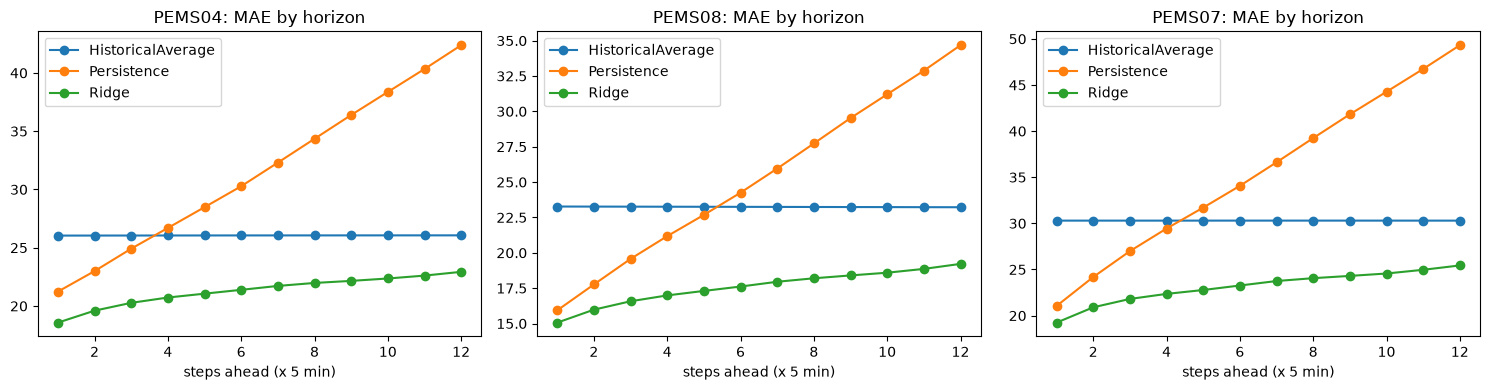

In [ ]:
multi = [n for n in SELECTED if DATASETS[n]["T_out"] > 1]   # a one-step dataset has no horizon curve
fig, axes = plt.subplots(1, len(multi), figsize=(5 * len(multi), 4), squeeze=False)
for ax, name in zip(axes[0], multi):
    d = metrics.query("dataset == @name and horizon != 'avg'").astype({"horizon": int})
    for model, g in d.groupby("model"):
        ax.plot(g.horizon, g.MAE, marker="o", label=model)
    ax.set_title(f"{name}: MAE by horizon"); ax.set_xlabel(f"steps ahead (x {DATASETS[name]['step_min']} min)"); ax.legend()
plt.tight_layout()

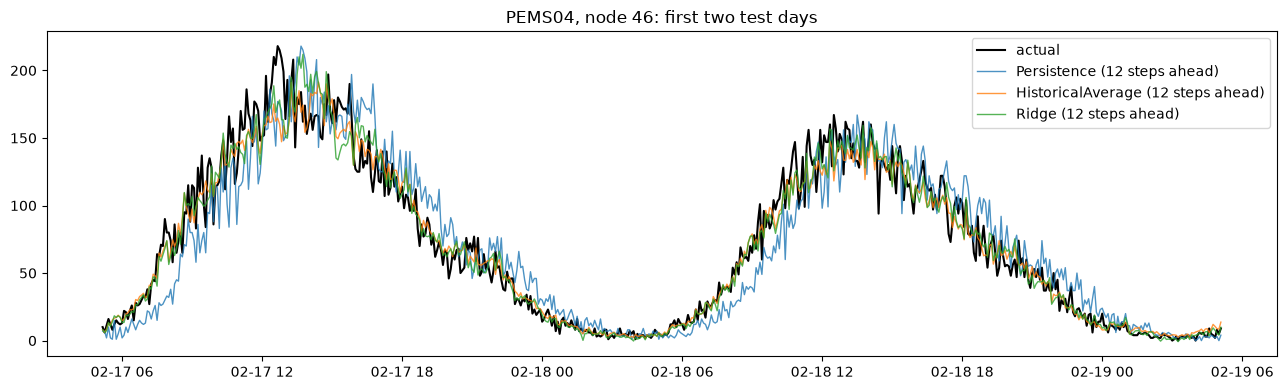

In [ ]:
name = SELECTED[0]
s = samples[name]; node = s.node.iloc[0]
d = s[s.node == node]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(d.time_hL, d.actual_hL, "k", lw=1.5, label="actual")
for model in ["Persistence", "HistoricalAverage", "Ridge"]:
    ax.plot(d.time_hL, d[f"{model}_hL"], lw=1, alpha=0.8, label=f"{model} ({DATASETS[name]['T_out']} steps ahead)")
ax.set_title(f"{name}, node {node}: first two test days"); ax.legend(); plt.tight_layout()

## What the baselines tell us

- **Persistence** is competitive one step ahead and degrades linearly with the horizon: the future
  resembles the present for five minutes, and not at all for an hour.
- **Historical Average** is flat across horizons — it never looks at the present — and lands roughly where
  Persistence ends up at 60 minutes. Its error is the price of ignoring today's specifics.
- **Ridge** takes the best of both (recent values + the usual profile) and wins at every horizon on every
  dataset — a strong, cheap bar. But its error still grows steadily with the horizon. Being linear and per-sensor, it cannot represent "the jam upstream will
  reach me in 15 minutes" — which is precisely the spatial-temporal, delay-aware structure a transformer
  over the sensor graph is meant to capture. That is the gap `drive_me_crazy_pdformer.ipynb` tries to close.